In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
from  sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub\Data_CSV\Social_Network_Ads.csv')

print("Dataset shape:", df.shape)

print("\nColumn information:")
print(df.info())

print("\nMissing values (Null):")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nDuplicated:")
print(df.duplicated().sum())

Dataset shape: (400, 5)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

Missing values (Null):
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Basic statistics:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.56267

In [4]:
def lableEncoderColumns(df):
  for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = LabelEncoder().fit_transform(df[i])
  return df

In [6]:
lableEncoderColumns(df)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


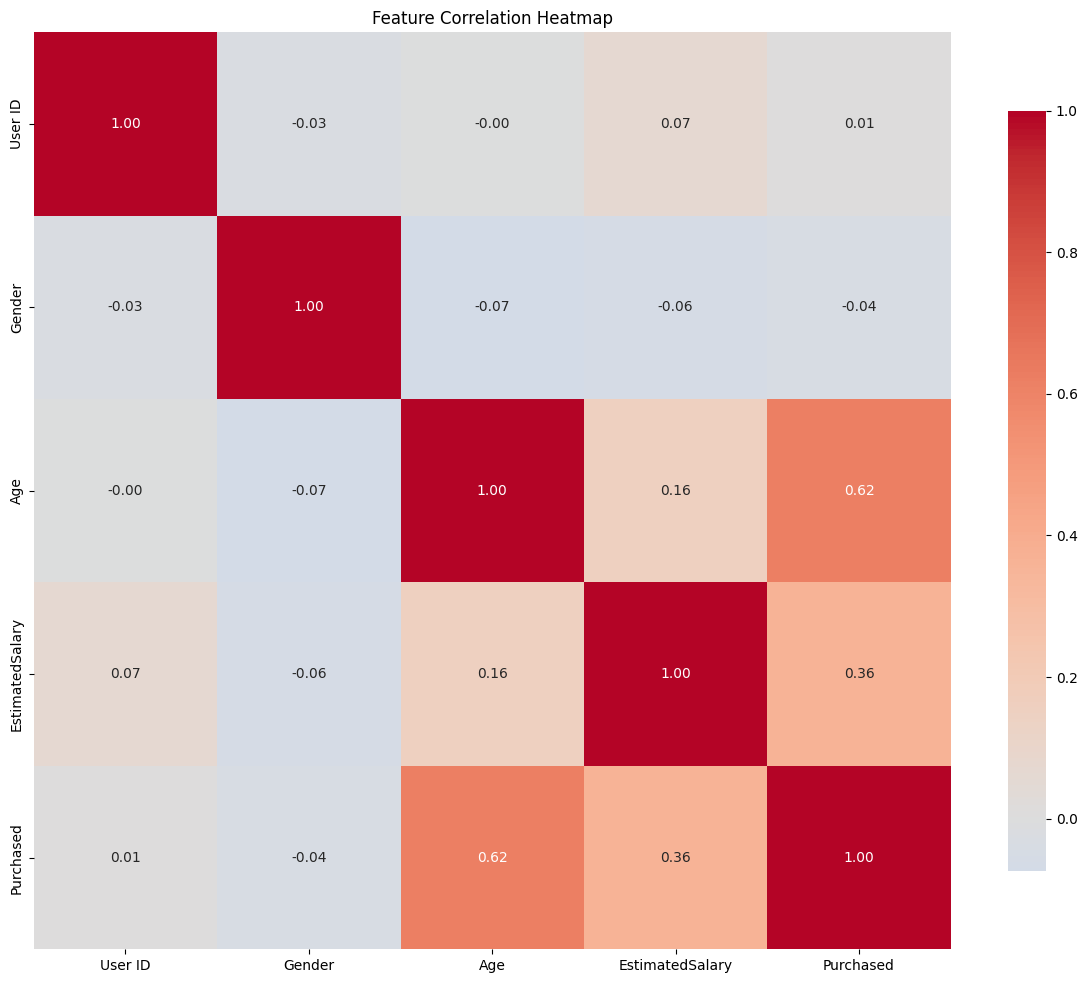

Top 10 features correlated with Purchased:
Purchased          1.000000
Age                0.622454
EstimatedSalary    0.362083
User ID            0.007120
Gender            -0.042469
Name: Purchased, dtype: float64

Bottom 10 features correlated with Purchased:
Purchased          1.000000
Age                0.622454
EstimatedSalary    0.362083
User ID            0.007120
Gender            -0.042469
Name: Purchased, dtype: float64

Selected 2 features with |correlation| > 0.1


In [8]:
def select_features_by_correlation(df, target_col, threshold=0.1):
    """
    Select features based on correlation with target variable
    """
  
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    target_corr = corr_matrix[target_col].sort_values(ascending=False)

    print(f"Top 10 features correlated with {target_col}:")
    print(target_corr.head(10))

    print(f"\nBottom 10 features correlated with {target_col}:")
    print(target_corr.tail(10))

    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
    selected_features.remove(target_col) 

    print(f"\nSelected {len(selected_features)} features with |correlation| > {threshold}")

    return selected_features, corr_matrix

selected_features, corr_matrix = select_features_by_correlation(df, 'Purchased', threshold=0.1)


In [9]:
df.drop(['User ID'], axis=1, inplace=True)

In [19]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
model = RandomForestClassifier(n_estimators=7 ,max_depth=5,random_state=42)
model.fit(X_train,y_train)

,n_estimators,7
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred) * 100

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R-squared: {r2}')
print(f"Accuracy: {acc:.2f}")

MAE: 0.09166666666666666
MSE: 0.09166666666666666
RMSE: 0.30276503540974914
R-squared: 0.6152725153016614
Accuracy: 90.83
